# Predição de Umidade do Solo com TFLite Micro

Notebook de treinamento e avaliação de um modelo compacto voltado para predição de umidade do solo em sistemas embarcados. O conjunto de dados utilizado é o Wazihub Soil Moisture Prediction, que reúne medições de quatro campos agrícolas em intervalos de cinco minutos; a saída do modelo é um nível de umidade discretizado no intervalo de 0 a 9, compatível com a representação do firmware no ESP32-S3.

O fluxo cobre preparação dos dados, treinamento da rede, conversão para TFLite, quantização pós-treinamento em int8 e avaliação comparativa entre as versões float e quantizada. O notebook pode ser executado tanto localmente (VS Code / Jupyter) quanto no Google Colab — se estiver fora do repositório, ele clona o projeto a partir do GitHub e, se o dataset não existir, baixa-o automaticamente antes de prosseguir. Os artefatos gerados ficam em `main/models/notebook_outputs/`.


In [1]:
# Configuração portátil do notebook (VS Code/Jupyter/Google Colab)
from pathlib import Path
import importlib.util
import os
import subprocess
import sys

PROJECT_REPO_URL = "https://github.com/p19091985/IA-Embarcada-e-Modelos-Compactos.git"
DATASET_REPO_URL = "https://github.com/ayamlearning/Wazihub_Soil_Moisture_Prediction.git"
DATASET_ZIP_URL = "https://github.com/ayamlearning/Wazihub_Soil_Moisture_Prediction/archive/refs/heads/master.zip"

REQUIRED_MODULES = {
    "tensorflow": "tensorflow",
    "absl": "absl-py",
    "numpy": "numpy",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
}

IS_COLAB = "google.colab" in sys.modules or "COLAB_RELEASE_TAG" in os.environ
missing = [pip_name for module_name, pip_name in REQUIRED_MODULES.items()
           if importlib.util.find_spec(module_name) is None]
if missing:
    print("Instalando pacotes ausentes:", ", ".join(missing))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)


def looks_like_repo(candidate: Path) -> bool:
    return (candidate / "README.md").exists() and (candidate / "diagram.json").exists()


def clone_project_for_colab(target: Path) -> Path:
    if looks_like_repo(target):
        return target
    target.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(["git", "clone", "--depth", "1", PROJECT_REPO_URL, str(target)], check=True)
    return target


def find_repo_root(start: Path) -> Path:
    env_root = os.environ.get("IA_EMBARCADA_REPO_ROOT")
    if env_root:
        candidate = Path(env_root).expanduser().resolve()
        if looks_like_repo(candidate):
            return candidate

    start = start.resolve()
    for candidate in [start, *start.parents]:
        if looks_like_repo(candidate):
            return candidate

    if IS_COLAB:
        return clone_project_for_colab(Path("/content/IA-Embarcada-e-Modelos-Compactos"))

    raise RuntimeError(
        "Não consegui localizar a raiz do repositório. "
        "Abra o notebook pelo VS Code na pasta do projeto ou defina IA_EMBARCADA_REPO_ROOT."
    )


REPO_ROOT = find_repo_root(Path.cwd())
os.chdir(REPO_ROOT)
DATASET_DIR = REPO_ROOT / "datasets" / "Wazihub_Soil_Moisture_Prediction"
DATASET_PATH = DATASET_DIR / "Dataset" / "Train.csv"
MODEL_DIR = REPO_ROOT / "main" / "models" / "notebook_outputs"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Python:", sys.executable)
print("Ambiente:", "Google Colab" if IS_COLAB else "local/Jupyter")
print("Raiz do projeto:", REPO_ROOT)
print("Dataset:", DATASET_PATH)
print("Saída dos modelos:", MODEL_DIR)


Python: /usr/bin/python3
Ambiente: Google Colab
Raiz do projeto: /content/IA-Embarcada-e-Modelos-Compactos
Dataset: /content/IA-Embarcada-e-Modelos-Compactos/datasets/Wazihub_Soil_Moisture_Prediction/Dataset/Train.csv
Saída dos modelos: /content/IA-Embarcada-e-Modelos-Compactos/main/models/notebook_outputs


## 1. Preparação dos dados e definição do modelo

Abaixo estão as rotinas de carregamento do CSV, construção das features e definição da arquitetura da rede. O modelo recebe nove atributos extraídos do dataset (umidade do solo, irrigação, variáveis climáticas e identificador de campo) e produz uma saída contínua que, no firmware, é mapeada para o intervalo 0–9.

| Etapa | Decisão técnica |
|---|---|
| Entrada | 9 atributos numéricos do CSV |
| Saída | Nível de umidade (0..9) |
| Modelo | Rede densa compacta, regressão |
| Exportação | Conversão p/ TFLite float |
| Deploy | Quantização int8, geração de header C |


In [2]:
import math
import os

from absl import logging
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt


FEATURE_COLUMNS = [
    "Soil humidity 1",
    "Irrigation field 1",
    "Air temperature (C)",
    "Air humidity (%)",
    "Pressure (KPa)",
    "Wind speed (Km/h)",
    "Wind gust (Km/h)",
    "Wind direction (Deg)",
]
FEATURE_LABELS = [
    "Umidade do solo",
    "Irrigação",
    "Temperatura do ar",
    "Umidade do ar",
    "Pressão",
    "Velocidade do vento",
    "Rajada de vento",
    "Direção do vento",
    "Campo",
]
INPUT_COUNT = 9
FIELD_ID = 1
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.keras.utils.set_random_seed(RANDOM_SEED)


def load_feature_frame(csv_path):
    """Carrega o CSV e organiza as features usadas pelo modelo."""
    df = pd.read_csv(csv_path)
    df = df.dropna(subset=FEATURE_COLUMNS).reset_index(drop=True)

    feature_df = pd.DataFrame({col: df[col].astype(np.float32) for col in FEATURE_COLUMNS})
    feature_df["field_id"] = float(FIELD_ID)
    feature_df["target_level"] = np.clip(
        feature_df["Soil humidity 1"] / feature_df["Soil humidity 1"].max() * 9.0,
        0.0,
        9.0,
    ).astype(np.float32)
    return feature_df


def get_data(csv_path):
    """Prepara entradas normalizadas e alvo numérico para o modelo de umidade do solo."""
    feature_df = load_feature_frame(csv_path)
    x_values = feature_df[[*FEATURE_COLUMNS, "field_id"]].to_numpy(dtype=np.float32)
    y_values = feature_df["target_level"].to_numpy(dtype=np.float32)

    feat_min = x_values.min(axis=0)
    feat_max = x_values.max(axis=0)
    span = feat_max - feat_min
    span[span < 1e-6] = 1.0

    x_normalized = np.clip((x_values - feat_min) / span, 0.0, 1.0).astype(np.float32)

    rng = np.random.default_rng(RANDOM_SEED)
    indices = rng.permutation(len(x_normalized))
    x_normalized = x_normalized[indices]
    y_values = y_values[indices]

    return x_normalized, y_values, feat_min, feat_max


def plot_dataset_overview(csv_path):
    """Gera gráficos exploratórios do conjunto de dados utilizado no treinamento."""
    feature_df = load_feature_frame(csv_path)
    print(f"Amostras disponíveis: {len(feature_df)}")

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    axes[0, 0].hist(feature_df["Soil humidity 1"], bins=35, color="#1f77b4", alpha=0.82)
    axes[0, 0].set_title("Distribuição da umidade do solo")
    axes[0, 0].set_xlabel("Umidade do solo (%)")
    axes[0, 0].set_ylabel("Frequência")

    axes[0, 1].hist(feature_df["target_level"], bins=np.arange(-0.5, 10.5, 1), color="#2ca02c", alpha=0.82)
    axes[0, 1].set_title("Distribuição do alvo")
    axes[0, 1].set_xlabel("Nível de umidade (0-9)")
    axes[0, 1].set_ylabel("Frequência")
    axes[0, 1].set_xticks(range(10))

    sample = feature_df.iloc[: min(500, len(feature_df))]
    axes[1, 0].scatter(sample.index, sample["Soil humidity 1"], s=14, alpha=0.55, label="Umidade")
    axes[1, 0].scatter(sample.index, sample["target_level"], s=14, alpha=0.55, label="Alvo 0-9")
    axes[1, 0].set_title("Primeiras amostras do dataset")
    axes[1, 0].set_xlabel("Índice da amostra")
    axes[1, 0].set_ylabel("Valor")
    axes[1, 0].legend()

    corr_columns = [*FEATURE_COLUMNS, "field_id", "target_level"]
    corr = feature_df[corr_columns].corr(numeric_only=True).fillna(0.0)
    image = axes[1, 1].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    axes[1, 1].set_title("Correlação entre variáveis")
    axes[1, 1].set_xticks(range(len(corr_columns)))
    axes[1, 1].set_yticks(range(len(corr_columns)))
    labels = [*FEATURE_LABELS, "Alvo"]
    axes[1, 1].set_xticklabels(labels, rotation=75, ha="right")
    axes[1, 1].set_yticklabels(labels)
    fig.colorbar(image, ax=axes[1, 1], fraction=0.046, pad=0.04)

    fig.tight_layout()
    plt.show()

    return feature_df


def create_model():
    """Define a rede neural de regressão compacta do projeto."""
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(INPUT_COUNT,)),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1),
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model


def convert_tflite_model(model):
    """Converte o modelo Keras treinado para o formato TensorFlow Lite."""
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()


def save_tflite_model(tflite_model, save_dir, model_name):
    """Persiste um modelo TensorFlow Lite no diretório informado."""
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, model_name)
    with open(save_path, "wb") as f:
        f.write(tflite_model)
    logging.info("Modelo TFLite salvo em %s", save_path)


def train_model(epochs, x_values, y_values, save_tf_model=False, save_dir="soil_models"):
    """Treina o modelo Keras e armazena o histórico para análise gráfica."""
    model = create_model()
    history = model.fit(
        x_values,
        y_values,
        epochs=epochs,
        validation_split=0.2,
        batch_size=64,
        verbose=2,
    )
    model.training_history = history.history

    if save_tf_model:
        if hasattr(model, "export"):
            model.export(save_dir)
        else:
            tf.saved_model.save(model, save_dir)
        logging.info("Modelo TensorFlow salvo em %s", save_dir)

    return model


def plot_training_history(model):
    """Apresenta as curvas de erro do treinamento e da validação."""
    history = getattr(model, "training_history", None)
    if not history:
        print("Histórico de treinamento indisponível.")
        return

    epochs = np.arange(1, len(history["loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(epochs, history["loss"], label="Treino", linewidth=2)
    if "val_loss" in history:
        axes[0].plot(epochs, history["val_loss"], label="Validação", linewidth=2)
    axes[0].set_title("Evolução da função de perda")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("MSE")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].plot(epochs, history["mae"], label="Treino", linewidth=2)
    if "val_mae" in history:
        axes[1].plot(epochs, history["val_mae"], label="Validação", linewidth=2)
    axes[1].set_title("Evolução do erro absoluto médio")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("MAE")
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    fig.tight_layout()
    plt.show()


def color_text(text, color_code):
    """Aplica cor ANSI a textos exibidos no console do notebook."""
    return f"\033[{color_code}m{text}\033[0m"


def print_boxed_lines(title, lines, color="36"):
    """Imprime um bloco textual organizado com bordas e cor ANSI."""
    plain_title = title
    width = max([len(plain_title), *(len(line) for line in lines)]) + 4
    border = "=" * width
    print(color_text(border, color))
    print(color_text(f"  {plain_title.center(width - 4)}  ", color))
    print(color_text(border, color))
    for line in lines:
        print(color_text(f"  {line.ljust(width - 4)}  ", color))
    print(color_text(border, color))


def print_soil_training_report(csv_path, model, feat_min, feat_max, save_dir, epochs):
    """Exibe a síntese acadêmica do treinamento do modelo de umidade do solo."""
    feature_df = load_feature_frame(csv_path)
    history = getattr(model, "training_history", {})
    final_loss = history.get("loss", [float("nan")])[-1]
    final_mae = history.get("mae", [float("nan")])[-1]
    final_val_loss = history.get("val_loss", [float("nan")])[-1]
    final_val_mae = history.get("val_mae", [float("nan")])[-1]

    print()
    print_boxed_lines(
        "Modelo de Umidade do Solo para IA Embarcada",
        [
            "Objetivo: estimar o nível de umidade do solo para apoio à irrigação.",
            "Base de dados: Wazihub Soil Moisture Prediction.",
            "Identidade do modelo: rede compacta treinada com dados agrícolas reais.",
            f"Artefatos salvos em: {save_dir}",
        ],
        color="35",
    )

    rows = [
        ("Entrada", f"{INPUT_COUNT} features normalizadas"),
        ("Alvo", "nível de umidade do solo 0..9"),
        ("Dados", f"Wazihub Soil Moisture ({len(feature_df)} amostras)"),
        ("Arquitetura", "Dense(16) -> Dense(16) -> Dense(1)"),
        ("Conversão", "Keras -> TensorFlow Lite"),
        ("Quantização", "int8 pós-treinamento"),
    ]
    print(color_text("\nResumo metodológico", "36"))
    print(color_text(f"{'Aspecto':<15} {'Configuração do projeto'}", "36"))
    print(color_text("-" * 72, "36"))
    for aspect, project_config in rows:
        print(f"{aspect:<15} {project_config}")

    print(color_text("\nConfiguração do treinamento", "32"))
    print(f"  Épocas configuradas : {epochs}")
    print(f"  Amostras utilizadas : {len(feature_df)}")
    print(f"  Features de entrada : {INPUT_COUNT}")
    print(f"  Campo representado  : {FIELD_ID}")
    print(f"  Loss final          : {final_loss:.6f}")
    print(f"  MAE final           : {final_mae:.6f}")
    print(f"  Val loss final      : {final_val_loss:.6f}")
    print(f"  Val MAE final       : {final_val_mae:.6f}")

    print(color_text("\nFeatures usadas pelo modelo", "33"))
    print(color_text(f"{'#':>2} {'Feature':<26} {'Mínimo':>12} {'Máximo':>12}", "33"))
    print(color_text("-" * 58, "33"))
    for index, (label, min_value, max_value) in enumerate(zip(FEATURE_LABELS, feat_min, feat_max), start=1):
        print(f"{index:>2} {label:<26} {float(min_value):>12.4f} {float(max_value):>12.4f}")
    print()

def train(csv_path, epochs=500, save_dir="soil_models", save_tf_model=True):
    """Executa o fluxo completo de treinamento e conversão para TensorFlow Lite."""
    x_values, y_values, feat_min, feat_max = get_data(csv_path)
    trained_model = train_model(
        epochs, x_values, y_values, save_tf_model=save_tf_model, save_dir=save_dir
    )

    tflite_model = convert_tflite_model(trained_model)
    save_tflite_model(tflite_model, save_dir, model_name="soil_moisture_level_float.tflite")

    print("\n--- Metadados para soil_model_metadata.h ---")
    print(f"Amostras: {len(x_values)}")
    print(f"Features: {INPUT_COUNT}")
    print(f"feat_min = {feat_min.tolist()}")
    print(f"feat_max = {feat_max.tolist()}")

    return trained_model, feat_min, feat_max


## 2. Análise exploratória

Distribuição das variáveis de entrada, histograma do alvo e matriz de correlação entre os atributos utilizados no treinamento. Esses gráficos ajudam a identificar problemas de escala, desbalanceamento ou colinearidade antes de treinar a rede.


Amostras disponíveis: 8914


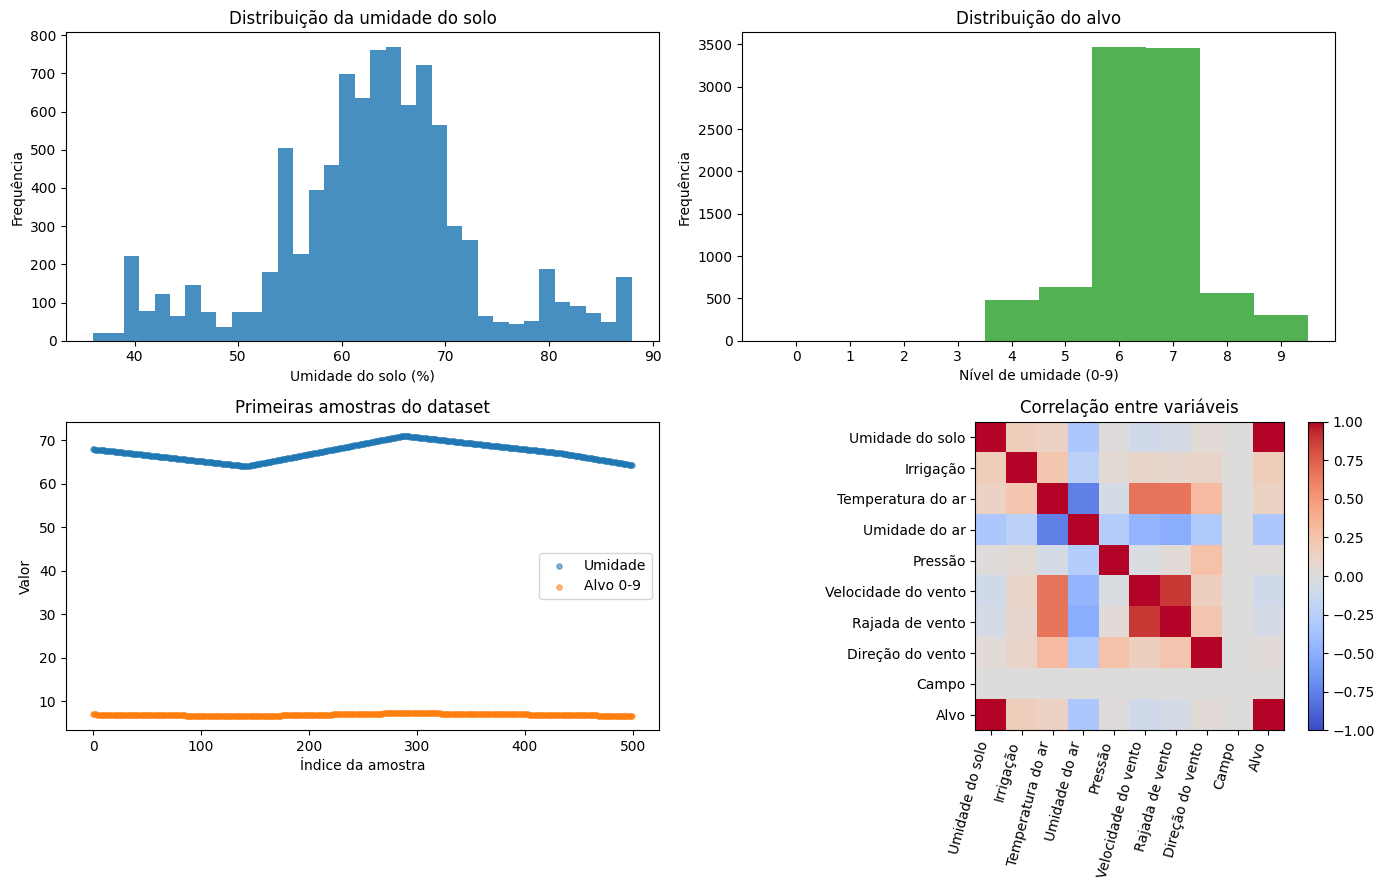

,count,mean,std,min,25%,50%,75%,max
Soil humidity 1,8914.0,63.032394,9.795766,36.000000,58.220001,63.000000,68.000000,88.000000
Irrigation field 1,8914.0,0.184429,0.387866,0.000000,0.000000,0.000000,0.000000,1.000000
Air temperature (C),8914.0,24.390928,7.151178,11.220000,18.309999,22.870001,30.670000,43.799999
Air humidity (%),8914.0,42.232101,32.599415,0.590000,11.730000,32.065001,73.234999,96.000000
Pressure (KPa),8914.0,101.235939,0.249358,100.580002,101.070000,101.250000,101.400002,101.860001
Wind speed (Km/h),8914.0,8.666717,4.420177,0.000000,5.320000,8.180000,11.580000,29.690001
Wind gust (Km/h),8914.0,39.314034,24.647648,0.000000,19.200001,34.820000,55.914999,133.330002
Wind direction (Deg),8914.0,115.955521,122.837563,0.000000,22.500000,22.500000,225.000000,337.500000
field_id,8914.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
target_level,8914.0,6.446495,1.001842,3.681818,5.954319,6.443182,6.954545,9.000000


In [3]:
# O dataset é baixado somente quando ainda não está disponível localmente.
import shutil
import tempfile
import urllib.request
import zipfile


def ensure_dataset(dataset_dir: Path) -> Path:
    csv_path = dataset_dir / "Dataset" / "Train.csv"
    if csv_path.exists():
        return csv_path

    dataset_dir.parent.mkdir(parents=True, exist_ok=True)
    try:
        subprocess.run(
            ["git", "clone", "--depth", "1", DATASET_REPO_URL, str(dataset_dir)],
            check=True,
        )
    except (FileNotFoundError, subprocess.CalledProcessError):
        if dataset_dir.exists():
            shutil.rmtree(dataset_dir)
        with tempfile.TemporaryDirectory() as tmp:
            tmp_path = Path(tmp)
            zip_path = tmp_path / "dataset.zip"
            urllib.request.urlretrieve(DATASET_ZIP_URL, zip_path)
            with zipfile.ZipFile(zip_path) as archive:
                archive.extractall(tmp_path)
            extracted_dirs = [item for item in tmp_path.iterdir() if item.is_dir()]
            if not extracted_dirs:
                raise FileNotFoundError("Dataset não encontrado no ZIP baixado.")
            shutil.move(str(extracted_dirs[0]), str(dataset_dir))

    if not csv_path.exists():
        raise FileNotFoundError(f"Dataset não encontrado: {csv_path}")
    return csv_path


DATASET_PATH = ensure_dataset(DATASET_DIR)
dataset_frame = plot_dataset_overview(str(DATASET_PATH))
dataset_frame.describe().T


## 3. Treinamento

A rede é treinada com os dados normalizados por min-max. As curvas de loss e MAE ao longo das épocas permitem verificar se houve convergência e se o modelo não está em overfitting em relação à partição de validação.


Epoch 1/60
112/112 - 3s - 29ms/step - loss: 38.1021 - mae: 6.0628 - val_loss: 24.8645 - val_mae: 4.8874
Epoch 2/60
112/112 - 1s - 6ms/step - loss: 8.5433 - mae: 2.4087 - val_loss: 1.3970 - val_mae: 0.9544
Epoch 3/60
112/112 - 1s - 6ms/step - loss: 1.1649 - mae: 0.8551 - val_loss: 1.0171 - val_mae: 0.8033
Epoch 4/60
112/112 - 2s - 14ms/step - loss: 0.8536 - mae: 0.7244 - val_loss: 0.7508 - val_mae: 0.6829
Epoch 5/60
112/112 - 2s - 17ms/step - loss: 0.6263 - mae: 0.6187 - val_loss: 0.5472 - val_mae: 0.5837
Epoch 6/60
112/112 - 1s - 5ms/step - loss: 0.4472 - mae: 0.5265 - val_loss: 0.3826 - val_mae: 0.4917
Epoch 7/60
112/112 - 1s - 5ms/step - loss: 0.3036 - mae: 0.4370 - val_loss: 0.2512 - val_mae: 0.4008
Epoch 8/60
112/112 - 0s - 3ms/step - loss: 0.1928 - mae: 0.3507 - val_loss: 0.1534 - val_mae: 0.3149
Epoch 9/60
112/112 - 0s - 3ms/step - loss: 0.1147 - mae: 0.2722 - val_loss: 0.0888 - val_mae: 0.2400
Epoch 10/60
112/112 - 0s - 3ms/step - loss: 0.0650 - mae: 0.2056 - val_loss: 0.0495 - 

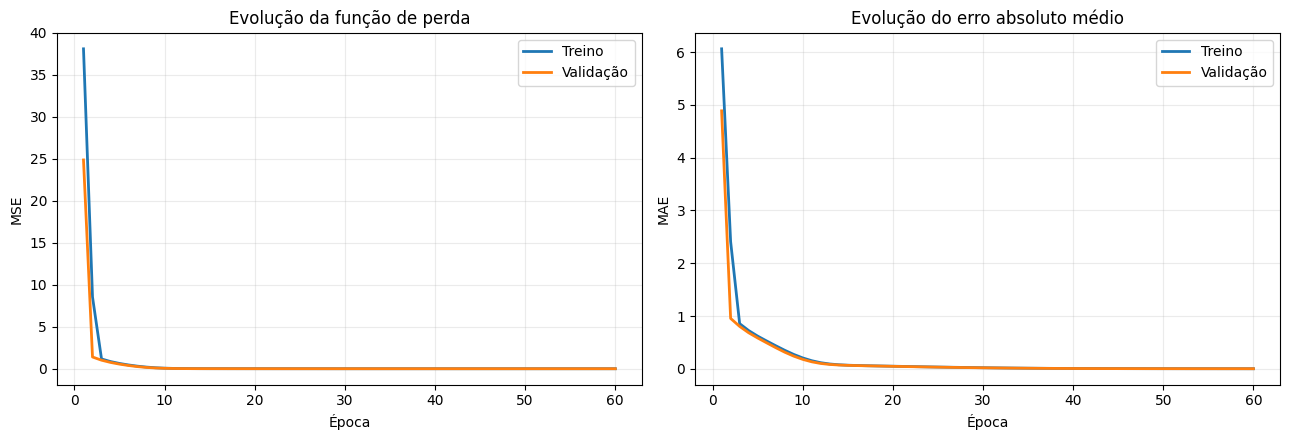

In [4]:
EPOCHS = 60
SAVE_TF_MODEL = True
SAVE_DIR = MODEL_DIR

trained_model, feat_min, feat_max = train(
    csv_path=str(DATASET_PATH),
    epochs=EPOCHS,
    save_dir=str(SAVE_DIR),
    save_tf_model=SAVE_TF_MODEL,
)

print_soil_training_report(
    csv_path=str(DATASET_PATH),
    model=trained_model,
    feat_min=feat_min,
    feat_max=feat_max,
    save_dir=str(SAVE_DIR),
    epochs=EPOCHS,
)

plot_training_history(trained_model)


## 4. Utilitários de avaliação

Funções auxiliares para rodar inferência via TFLite Interpreter, calcular MAE/RMSE e gerar os gráficos diagnósticos (predição vs ground truth, scatter, distribuição de resíduos). Essas rotinas são reutilizadas nas seções seguintes para avaliar tanto o modelo float quanto o quantizado.


In [5]:
import os

from absl import logging
import numpy as np
import matplotlib.pyplot as plt

runtime = None
try:
    from tflite_micro.python.tflite_micro import runtime
except ImportError:
    logging.warning("Runtime tflite_micro indisponível. O TensorFlow Lite Interpreter será utilizado.")

try:
    from tensorflow.lite.python import interpreter as tflite_interp
    from tensorflow.lite.python.interpreter import OpResolverType
except ImportError:
    import tensorflow.lite as tflite_interp
    OpResolverType = None


def prepare_quantized_input(x_value, input_shape, input_details):
    """Prepara uma amostra para modelos quantizados int8/uint8."""
    input_data = np.reshape(x_value, input_shape)
    quantization = input_details.get("quantization", (0.0, 0))
    scale, zero_point = quantization

    if input_details["dtype"] in (np.int8, np.uint8) and scale not in (0, 0.0):
        quantized = np.round(input_data / scale + zero_point)
        dtype_info = np.iinfo(input_details["dtype"])
        quantized = np.clip(quantized, dtype_info.min, dtype_info.max)
        return quantized.astype(input_details["dtype"])

    return input_data.astype(input_details["dtype"])


def dequantize_output(output_tensor, output_details):
    """Converte a saída quantizada para valor em ponto flutuante, quando aplicável."""
    output_value = np.reshape(output_tensor, -1)[0]
    quantization = output_details.get("quantization", (0.0, 0))
    scale, zero_point = quantization

    if output_details["dtype"] in (np.int8, np.uint8) and scale not in (0, 0.0):
        return float((output_value - zero_point) * scale)

    return float(output_value)


def invoke_tflite_interpreter(input_shape, interpreter, x_value, input_details, output_details):
    """Executa uma inferência do TensorFlow Lite Interpreter."""
    input_data = prepare_quantized_input(x_value, input_shape, input_details)
    interpreter.set_tensor(input_details["index"], input_data)
    interpreter.invoke()
    tflite_output = interpreter.get_tensor(output_details["index"])
    return dequantize_output(tflite_output, output_details)


def calculate_regression_metrics(y_true, y_pred):
    """Calcula métricas de regressão para as predições obtidas."""
    errors = y_pred - y_true
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(np.square(errors))))
    return {"mae": mae, "rmse": rmse}


def get_tflite_prediction(model_path, x_values):
    """Executa o modelo TFLite para todas as amostras de teste."""
    kwargs = {"model_path": model_path}
    if OpResolverType is not None and hasattr(OpResolverType, "BUILTIN_REF"):
        kwargs["experimental_op_resolver_type"] = OpResolverType.BUILTIN_REF

    tflite_interpreter = tflite_interp.Interpreter(**kwargs)
    tflite_interpreter.allocate_tensors()

    input_details = tflite_interpreter.get_input_details()[0]
    output_details = tflite_interpreter.get_output_details()[0]
    input_shape = np.array(input_details.get("shape"))

    y_predictions = np.empty(len(x_values), dtype=np.float32)
    for i, x_value in enumerate(x_values):
        y_predictions[i] = invoke_tflite_interpreter(
            input_shape, tflite_interpreter, x_value, input_details, output_details,
        )
    return y_predictions


def plot_prediction_diagnostics(y_true, y_pred, model_label, metrics):
    """Gera gráficos de diagnóstico para a avaliação do modelo."""
    sample_count = min(300, len(y_true))
    residuals = y_pred - y_true

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

    axes[0].plot(range(sample_count), y_true[:sample_count], ".", label="Valor real", alpha=0.65)
    axes[0].plot(range(sample_count), y_pred[:sample_count], ".", label="Predição", alpha=0.65)
    axes[0].set_title(f"Predições por amostra — {model_label}")
    axes[0].set_xlabel("Amostra")
    axes[0].set_ylabel("Nível de umidade (0-9)")
    axes[0].legend()
    axes[0].grid(alpha=0.2)

    axes[1].scatter(y_true, y_pred, s=18, alpha=0.45)
    min_axis = float(min(np.min(y_true), np.min(y_pred)))
    max_axis = float(max(np.max(y_true), np.max(y_pred)))
    axes[1].plot([min_axis, max_axis], [min_axis, max_axis], "k--", linewidth=1)
    axes[1].set_title("Valor real versus predição")
    axes[1].set_xlabel("Valor real")
    axes[1].set_ylabel("Predição")
    axes[1].grid(alpha=0.2)

    axes[2].hist(residuals, bins=35, color="#d62728", alpha=0.78)
    axes[2].axvline(0, color="black", linestyle="--", linewidth=1)
    axes[2].set_title("Distribuição dos resíduos")
    axes[2].set_xlabel("Predição - valor real")
    axes[2].set_ylabel("Frequência")
    axes[2].grid(alpha=0.2)

    fig.suptitle(f"{model_label}: MAE={metrics['mae']:.4f}, RMSE={metrics['rmse']:.4f}", y=1.04)
    fig.tight_layout()
    plt.show()


def evaluate(model_path, x_test, y_test, use_tflite=True, model_label=None, show_plot=True):
    """Avalia o modelo TFLite e retorna métricas e predições."""
    if model_label is None:
        model_label = "TFLite"

    y_predictions = get_tflite_prediction(model_path, x_test)
    metrics = calculate_regression_metrics(y_test, y_predictions)
    metrics["predictions"] = y_predictions
    metrics["residuals"] = y_predictions - y_test

    print(f"{model_label} MAE: {metrics['mae']:.6f} | {model_label} RMSE: {metrics['rmse']:.6f}")

    if show_plot:
        plot_prediction_diagnostics(y_test, y_predictions, model_label, metrics)

    return metrics


## 5. Quantização pós-treinamento

Conversão do SavedModel para uma representação int8. Um dataset representativo (subconjunto do treino) é fornecido ao conversor para calibrar os ranges de ativação. O resultado é um `.tflite` cujos pesos e ativações operam em 8 bits, adequado para execução no ESP32-S3 via TFLite Micro.


In [6]:
"""Rotinas de quantização pós-treinamento para o modelo TensorFlow Lite."""
import math
import os

from absl import logging
import numpy as np
import tensorflow as tf


def get_calibration_data(csv_path):
    """Carrega amostras normalizadas para a calibração da quantização."""
    x_norm, _, _, _ = get_data(csv_path)
    return x_norm


def convert_quantized_tflite_model(source_model_dir, x_values):
    """Converte o SavedModel para TensorFlow Lite int8 com representative dataset."""
    def representative_dataset(num_samples=500):
        for i in range(min(num_samples, len(x_values))):
            yield [x_values[i].reshape(1, INPUT_COUNT)]

    converter = tf.lite.TFLiteConverter.from_saved_model(source_model_dir)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    converter.representative_dataset = representative_dataset
    return converter.convert()


def quantize(csv_path, source_model_dir="soil_models", target_dir="soil_models"):
    """Executa a quantização e grava o modelo int8."""
    x_values = get_calibration_data(csv_path)
    quantized_tflite_model = convert_quantized_tflite_model(source_model_dir, x_values)
    save_tflite_model(
        quantized_tflite_model, target_dir, model_name="soil_moisture_level_int8.tflite"
    )


### 5.1 Execução da quantização

Geração do arquivo `soil_moisture_level_int8.tflite` a partir do SavedModel produzido na etapa de treinamento.


In [7]:
SOURCE_MODEL_DIR = MODEL_DIR
TARGET_DIR = MODEL_DIR

quantize(
    csv_path=str(DATASET_PATH),
    source_model_dir=str(SOURCE_MODEL_DIR),
    target_dir=str(TARGET_DIR),
)


## 6. Avaliação do modelo float

Avaliação do modelo em ponto flutuante sobre a partição de teste. Os gráficos mostram a predição amostra a amostra, a dispersão entre valor real e predito e a distribuição dos resíduos.


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Modelo float MAE: 0.001288 | Modelo float RMSE: 0.002529


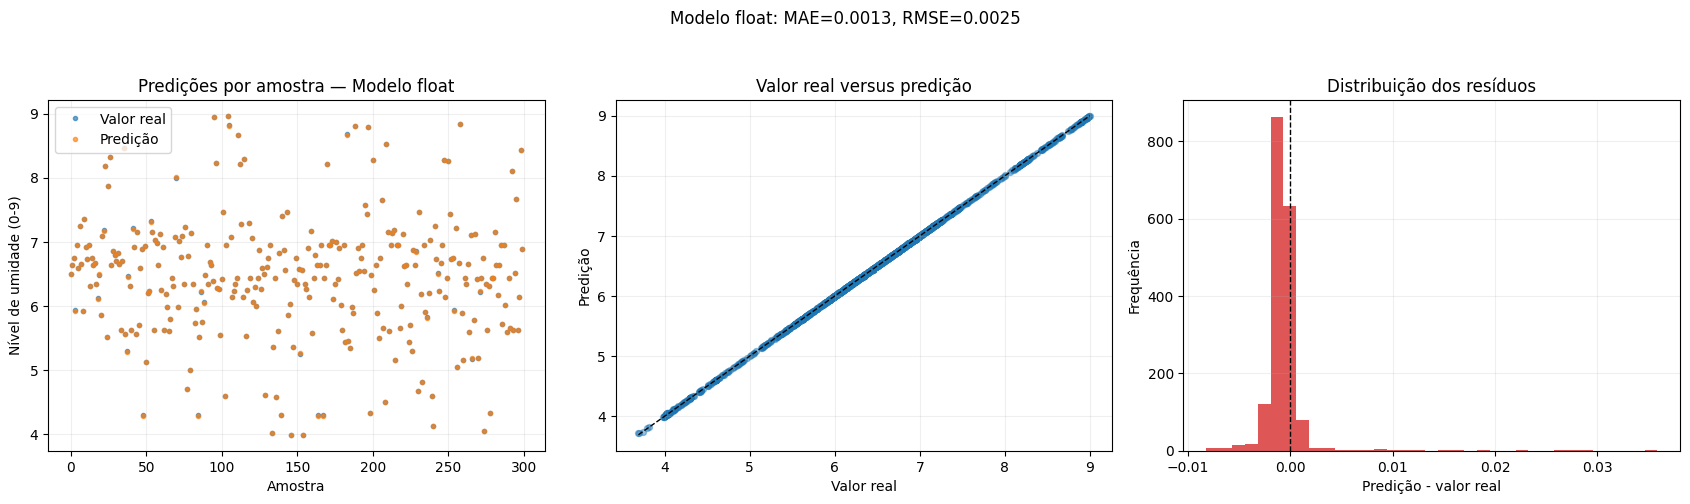

In [8]:
EVAL_MODEL_PATH = MODEL_DIR / "soil_moisture_level_float.tflite"

x_all, y_all, _, _ = get_data(str(DATASET_PATH))
n_test = int(0.2 * len(x_all))
x_test = x_all[:n_test]
y_test = y_all[:n_test]

float_metrics = evaluate(
    model_path=str(EVAL_MODEL_PATH),
    x_test=x_test,
    y_test=y_test,
    model_label="Modelo float",
)


## 7. Avaliação do modelo quantizado

Mesma avaliação da seção anterior, agora sobre o modelo int8. A comparação permite observar se a redução de 32 para 8 bits por peso introduziu degradação perceptível no erro de regressão.


/tmp/ipykernel_5723/475411879.py:43: RuntimeWarning: overflow encountered in scalar subtract
  return float((output_value - zero_point) * scale)


Modelo quantizado MAE: 8.461138 | Modelo quantizado RMSE: 8.726392


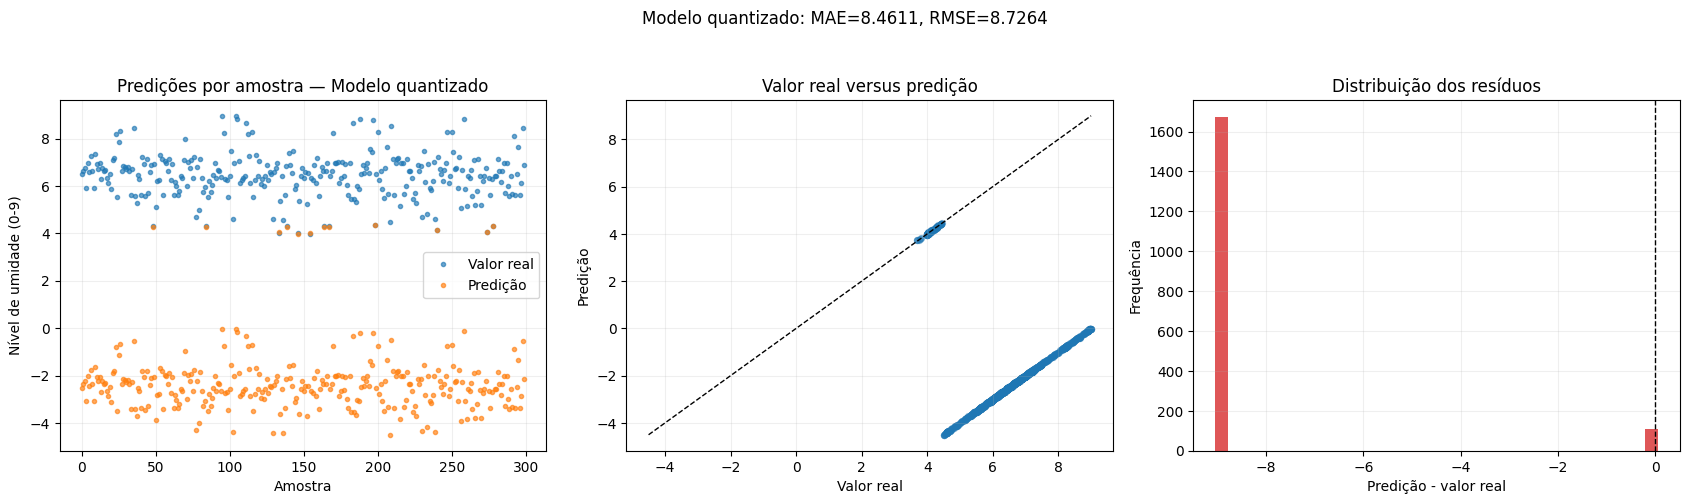

In [9]:
QUANTIZED_MODEL_PATH = MODEL_DIR / "soil_moisture_level_int8.tflite"

quantized_metrics = evaluate(
    model_path=str(QUANTIZED_MODEL_PATH),
    x_test=x_test,
    y_test=y_test,
    model_label="Modelo quantizado",
)


## 8. Comparação dos resultados

Tabela consolidada com MAE e RMSE de ambos os modelos, acompanhada de gráficos comparativos. O objetivo é verificar se o delta de erro entre float e int8 se mantém dentro de uma faixa aceitável para o domínio de aplicação.


,Modelo,MAE,RMSE
0,Modelo float,0.001288,0.002529
1,Modelo quantizado,8.461138,8.726392


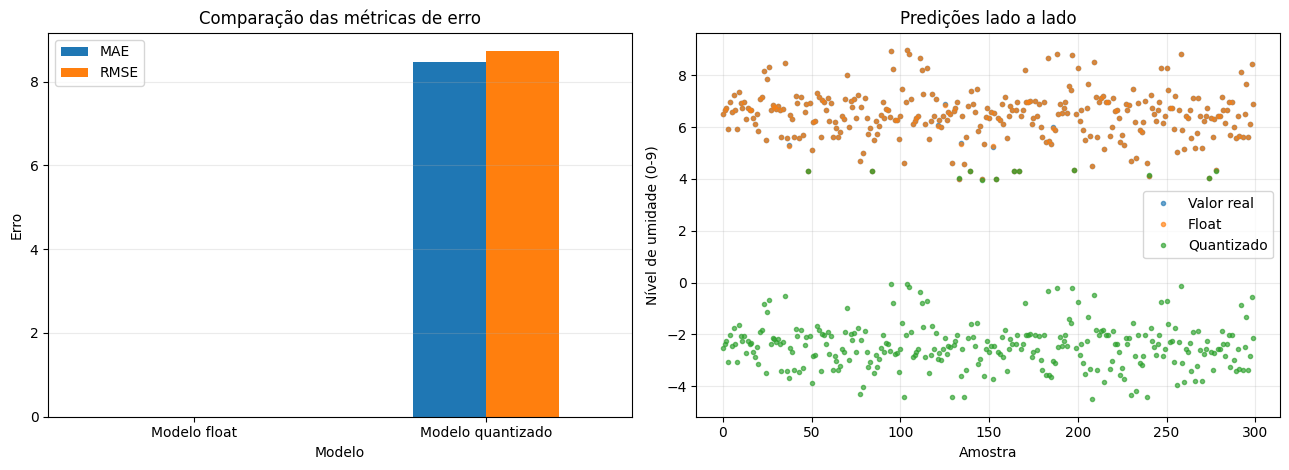

Delta (modelo quantizado - modelo float)
MAE delta : 8.459850
RMSE delta: 8.723863


,Modelo,MAE,RMSE
0,Modelo float,0.001288,0.002529
1,Modelo quantizado,8.461138,8.726392


In [10]:
comparison_rows = [
    ("Modelo float", float_metrics["mae"], float_metrics["rmse"]),
    ("Modelo quantizado", quantized_metrics["mae"], quantized_metrics["rmse"]),
]
comparison_df = pd.DataFrame(comparison_rows, columns=["Modelo", "MAE", "RMSE"])

try:
    display(comparison_df)
except NameError:
    print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
comparison_df.plot(x="Modelo", y=["MAE", "RMSE"], kind="bar", ax=axes[0], rot=0)
axes[0].set_title("Comparação das métricas de erro")
axes[0].set_ylabel("Erro")
axes[0].grid(axis="y", alpha=0.25)

sample_count = min(300, len(y_test))
axes[1].plot(range(sample_count), y_test[:sample_count], ".", label="Valor real", alpha=0.65)
axes[1].plot(range(sample_count), float_metrics["predictions"][:sample_count], ".", label="Float", alpha=0.65)
axes[1].plot(range(sample_count), quantized_metrics["predictions"][:sample_count], ".", label="Quantizado", alpha=0.65)
axes[1].set_title("Predições lado a lado")
axes[1].set_xlabel("Amostra")
axes[1].set_ylabel("Nível de umidade (0-9)")
axes[1].legend()
axes[1].grid(alpha=0.25)

fig.tight_layout()
plt.show()

mae_delta = quantized_metrics["mae"] - float_metrics["mae"]
rmse_delta = quantized_metrics["rmse"] - float_metrics["rmse"]

print("Delta (modelo quantizado - modelo float)")
print(f"MAE delta : {mae_delta:.6f}")
print(f"RMSE delta: {rmse_delta:.6f}")

comparison_df
